11.	Perform k- means clustering algorithm for customer segmentation from given features. Utilize Euclidean distance and Manhattan distance for this problem. Also, plot in terms of 2D and 3D clusters this problem.

Dataset: Customer segmentation dataset


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
df = pd.read_csv("Cust_Segmentation.csv")
df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2


In [ ]:
df_clean = df.drop(columns=["Customer Id", "Address"])

In [ ]:
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(df_clean)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [ ]:
pca_2d = PCA(n_components=2).fit_transform(X_scaled)
pca_3d = PCA(n_components=3).fit_transform(X_scaled)

In [ ]:
kmeans_euclidean = KMeans(n_clusters=3, random_state=42)
labels_euclidean = kmeans_euclidean.fit_predict(X_scaled)

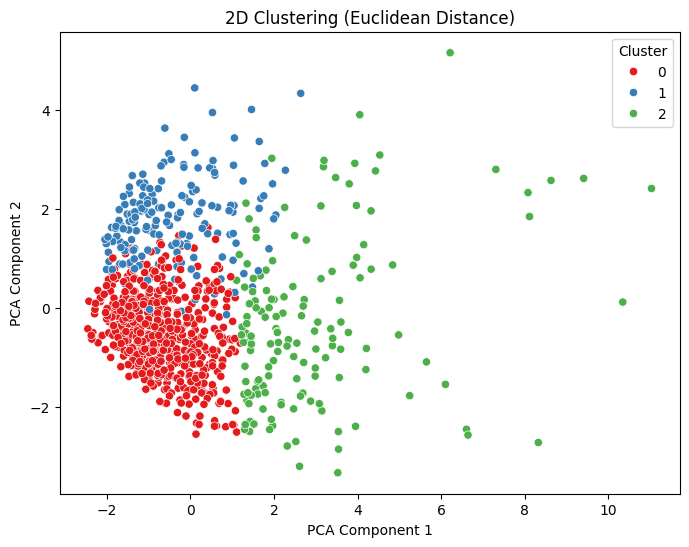

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_2d[:, 0], y=pca_2d[:, 1], hue=labels_euclidean, palette="Set1")
plt.title("2D Clustering (Euclidean Distance)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

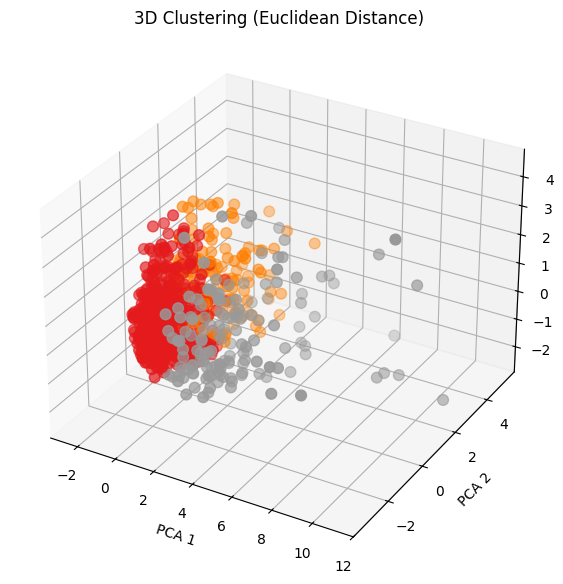

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(pca_3d[:, 0], pca_3d[:, 1], pca_3d[:, 2], c=labels_euclidean, cmap="Set1", s=60)
ax.set_title("3D Clustering (Euclidean Distance)")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
plt.show()

In [ ]:
manhattan_dist = pairwise_distances(X_scaled, metric='manhattan')

In [ ]:
kmeans_manhattan = KMeans(n_clusters=3, random_state=42)
labels_manhattan = kmeans_manhattan.fit_predict(manhattan_dist)

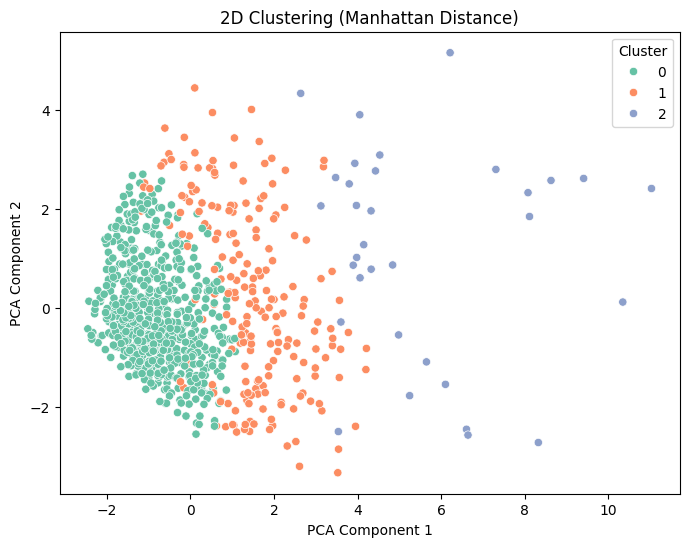

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_2d[:, 0], y=pca_2d[:, 1], hue=labels_manhattan, palette="Set2")
plt.title("2D Clustering (Manhattan Distance)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

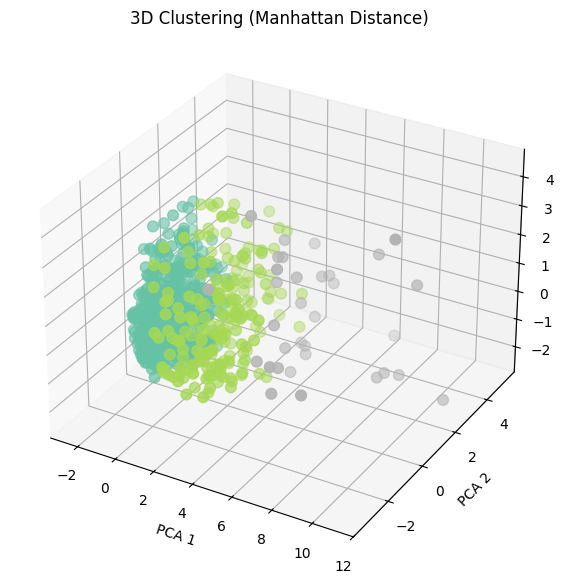

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(pca_3d[:, 0], pca_3d[:, 1], pca_3d[:, 2], c=labels_manhattan, cmap="Set2", s=60)
ax.set_title("3D Clustering (Manhattan Distance)")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
plt.show()